# **Yes Bank Stock Closing Price Prediction - EDA**

##### **Project Type**    - EDA (Exploratory Data Analysis)
##### **Contribution**    - Individual

**NAME : HARINI S**

# **Project Summary -**

Yes Bank is one of India's prominent private sector banks that has been in the spotlight since 2018 due to a well-publicised fraud case involving co-founder Rana Kapoor. This event triggered a sharp decline in the bank's stock price, drastically affecting its position in the market. This project analyses the monthly stock price history of Yes Bank from July 2005 to November 2020, covering the **Open, High, Low, and Close** prices for each month.

The primary objective of this EDA is to understand the behaviour of Yes Bank's stock price over a 15-year period, uncover long-term trends, seasonal patterns, and volatility characteristics, and specifically to visualise and quantify the impact of the 2018 fraud disclosure on the stock's valuation. The analysis moves through data cleaning, feature engineering (deriving Year, Month, monthly Returns, Volatility as High-Low spread, and moving averages), univariate exploration of each price variable, bivariate exploration of price relationships and time trends, and finally multivariate exploration through correlation and pairwise analysis.

Key findings show that the stock exhibited strong, steady growth from 2005 through 2017, reaching an all-time high around August 2018, before collapsing by more than 90% within about two years following the fraud revelation and subsequent RBI-led reconstruction of the bank's board in March 2020. Volatility (the High-Low spread) increased dramatically during the crash period, while monthly returns swung from consistently positive to extremely negative and erratic. The four price variables (Open, High, Low, Close) are extremely highly correlated with each other throughout, as expected for a single stock's OHLC data on a monthly frequency.

This EDA does not build a predictive model; instead, it lays the groundwork for one; by identifying which engineered features (lagged prices, moving averages, volatility) carry signal, and by documenting the structural break in the data caused by the fraud event, so any future regression/forecasting model can account for this regime change rather than be misled by it.

Overall, the notebook produces 20+ charts following the Univariate - Bivariate - Multivariate (UBM) analysis structure, each with an explanation of why the chart was chosen, the insight extracted, and its business implication.

# **GitHub Link -**

https://github.com/Harini085/YesBank-Stock-Price-Prediction-ml-and-eda/

# **Problem Statement**

Yes Bank's stock price experienced extreme volatility over the last two decades, most notably a catastrophic collapse following the 2018 fraud case involving its founder. Given only the monthly Open, High, Low and Close prices from 2005-2020, the goal is to explore this data to understand:

- How has Yes Bank's stock price evolved over time?
- What impact did the 2018 fraud disclosure have on price levels and volatility?
- Are there seasonal or cyclical patterns in the stock's performance?
- How are Open, High, Low and Close related to one another?
- What features (returns, volatility, moving averages) best describe the stock's risk/return profile, and could later support a price-prediction model?

#### **Define Your Business Objective?**

To perform a thorough exploratory analysis of Yes Bank's historical stock prices so that investors, risk analysts, and the bank's own management can understand the stock's long-term trend, the magnitude and timing of the 2018-2020 crash, and the resulting volatility profile — providing a data-driven foundation for risk assessment and any subsequent predictive modelling of the closing price.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.

     The additional credits will have advantages over other students during Star Student selection.

           [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                     without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.


```
# Chart visualization code
```


*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Plot style settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
%matplotlib inline

### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv('data_YesBank_StockPrices.csv')

### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 185
Number of Columns : 5


### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    str    
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), str(1)
memory usage: 7.4 KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

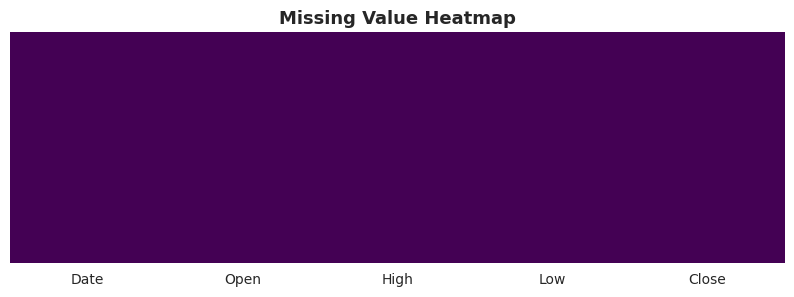

In [ ]:
# Visualizing the missing values
plt.figure(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap')
plt.show()

### What did you know about your dataset?

The dataset contains **185 monthly observations** of Yes Bank's stock price from **July 2005 to November 2020**, with **5 columns**: `Date` (month-year string), and the OHLC prices `Open`, `High`, `Low`, `Close` (all in INR).

- There are **no missing values** and **no duplicate rows** — the dataset is already clean at the row level.
- All four price columns are numeric (float), while `Date` is currently stored as text (e.g. `Jul-05`) and needs to be converted to a proper datetime type before any time-based analysis.
- Because the data is monthly (not daily), it summarises an entire month into 4 numbers, which is enough to study long-term trend and volatility but not intraday behaviour.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='str')

In [ ]:
# Dataset Describe
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

| Column | Description |
|---|---|
| `Date` | Month and year of observation (e.g. `Jul-05` = July 2005) |
| `Open` | Stock price (INR) at the start of the month |
| `High` | Highest stock price (INR) recorded during the month |
| `Low` | Lowest stock price (INR) recorded during the month |
| `Close` | Stock price (INR) at the end of the month |

All four price fields are continuous numerical variables. `Close` is the primary variable of interest since it represents the month-end valuation typically used for return calculations.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

Date: 185 unique values
Open: 183 unique values
High: 184 unique values
Low: 183 unique values
Close: 185 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.

# 1. Parse 'Date' (format 'Mon-YY') into a proper datetime (assume 20xx for 2-digit years)
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')

# 2. Sort chronologically and reset index (safety, in case rows were out of order)
df = df.sort_values('Date').reset_index(drop=True)

# 3. Extract Year and Month for grouping/seasonality analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

# 4. Feature engineering
df['Volatility'] = df['High'] - df['Low']                       # monthly trading range
df['Change'] = df['Close'] - df['Open']                          # net move within the month
df['Monthly_Return_%'] = df['Close'].pct_change() * 100          # month-over-month % return
df['Cumulative_Return_%'] = (df['Close'] / df['Close'].iloc[0] - 1) * 100
df['MA_3'] = df['Close'].rolling(window=3).mean()                # 3-month moving average
df['MA_6'] = df['Close'].rolling(window=6).mean()                # 6-month moving average

df.head()

,Date,Open,High,Low,Close,Year,Month,Month_Name,Volatility,Change,Monthly_Return_%,Cumulative_Return_%,MA_3,MA_6
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7,Jul,2.75,-0.54,NaN,0.000000,NaN,NaN
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8,Aug,2.33,0.84,7.704655,7.704655,NaN,NaN
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9,Sep,2.60,-0.18,-0.894188,6.741573,13.060000,NaN
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10,Oct,2.07,-0.21,-2.330827,4.253612,13.236667,NaN
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11,Nov,1.00,0.06,3.233256,7.624398,13.233333,NaN


### What all manipulations have you done and insights you found?

- Converted the text `Date` column into a proper `datetime` type and sorted the data chronologically, which is essential for any time-series line chart or rolling calculation.
- Derived `Year`, `Month`, and `Month_Name` to support seasonality (bivariate categorical-numerical) analysis.
- Engineered `Volatility` (High - Low) as a simple proxy for intra-month risk, `Change` (Close - Open) to see whether a month closed up or down, `Monthly_Return_%` for the standard percentage return investors care about, `Cumulative_Return_%` to show total growth since the start of the series, and `MA_3`/`MA_6` moving averages to smooth out month-to-month noise and reveal the underlying trend.
- No rows needed to be dropped — the data was already complete and duplicate-free, so wrangling was purely about type conversion and feature creation, not cleaning.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Distribution of Closing Price

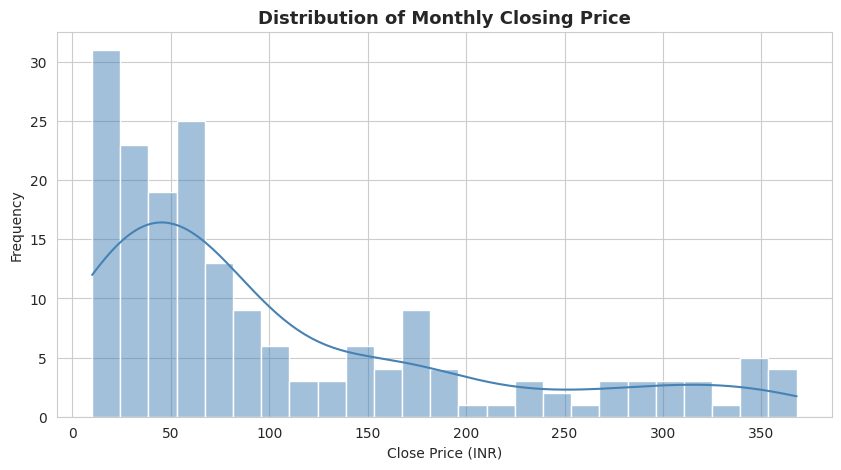

In [ ]:
# Chart - 1 visualization code
plt.figure(figsize=(10, 5))
sns.histplot(df['Close'], bins=25, kde=True, color='steelblue')
plt.title('Distribution of Monthly Closing Price')
plt.xlabel('Close Price (INR)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay is the standard way to see the shape, spread, and skew of a single continuous variable like closing price.

##### 2. What is/are the insight(s) found from the chart?

The distribution is heavily right-skewed: most months' closing prices cluster below INR 50, with a long tail stretching towards INR 350+. This confirms the stock spent most of its life at low-to-moderate valuations, with the very high prices being a comparatively short-lived era (2017-2018).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding that high valuations were an outlier period rather than the norm helps set realistic price expectations and avoid anchoring bias when comparing to the pre-2017 baseline. No negative growth implication by itself; it is descriptive.

#### Chart - 2 - Distribution of Opening Price

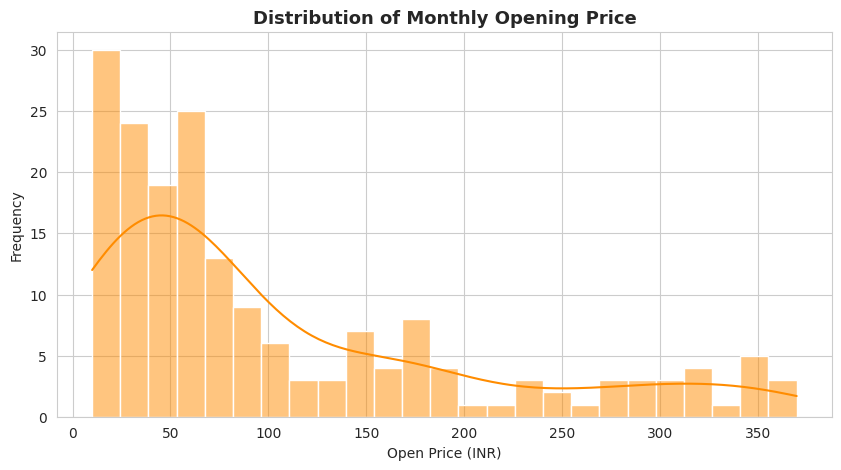

In [ ]:
# Chart - 2 visualization code
plt.figure(figsize=(10, 5))
sns.histplot(df['Open'], bins=25, kde=True, color='darkorange')
plt.title('Distribution of Monthly Opening Price')
plt.xlabel('Open Price (INR)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

Mirrors the Close price distribution chart so the two can be visually compared for consistency.

##### 2. What is/are the insight(s) found from the chart?

The Open price distribution is almost identical in shape to Close (right-skewed, same range), which is expected since Open and Close of a given month are typically close to each other.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — confirming Open and Close are similarly distributed validates that either could be used somewhat interchangeably as a monthly price proxy, simplifying later feature selection.

#### Chart - 3 - Distribution of High Price

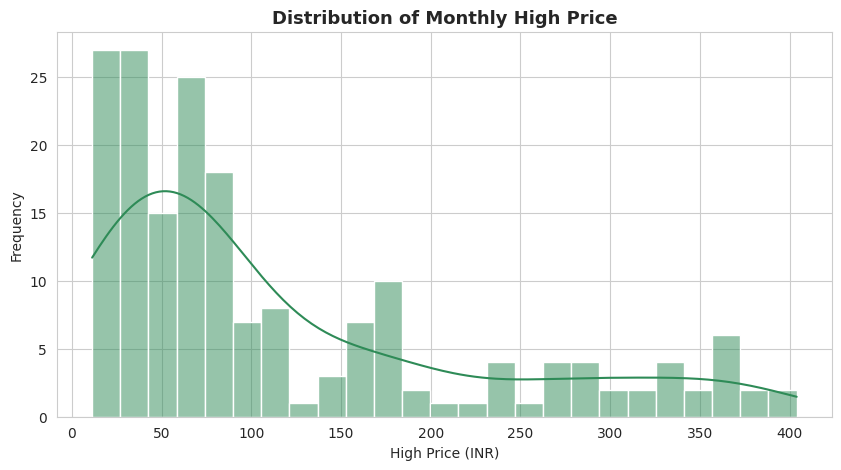

In [ ]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 5))
sns.histplot(df['High'], bins=25, kde=True, color='seagreen')
plt.title('Distribution of Monthly High Price')
plt.xlabel('High Price (INR)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

Completes the univariate view across all four OHLC variables so extremes (High) can be compared to the central Close/Open distributions.

##### 2. What is/are the insight(s) found from the chart?

High shows the same right skew but with a slightly longer tail and higher maximum (~404), since it captures the single highest tick of the month rather than the closing level.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — the extended tail on High signals that intra-month spikes were more extreme than closing levels suggest, useful context for risk/margin calculations, though it does not by itself indicate negative growth.

#### Chart - 4 - Distribution of Low Price

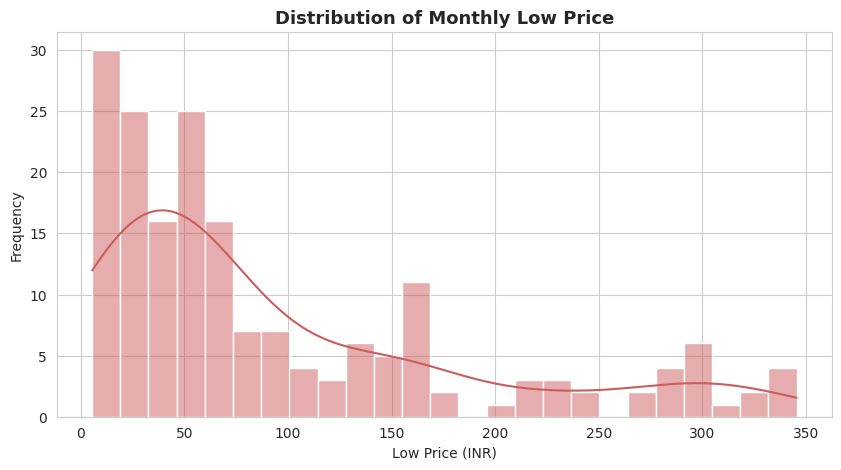

In [ ]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 5))
sns.histplot(df['Low'], bins=25, kde=True, color='indianred')
plt.title('Distribution of Monthly Low Price')
plt.xlabel('Low Price (INR)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

Completes the OHLC univariate comparison; Low is the natural counterpart to High.

##### 2. What is/are the insight(s) found from the chart?

Low has the most compressed right tail of all four variables (max ~15% lower than Close's max), and a floor around INR 5-11 that appears repeatedly in the post-2019 data — the price never fully recovered.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — a persistently low floor after 2019 is a negative-growth signal: it shows the stock failed to find support at historical trading levels, useful for setting stop-loss/valuation floors.

#### Chart - 5 - Boxplot of OHLC Prices (Outlier Check)

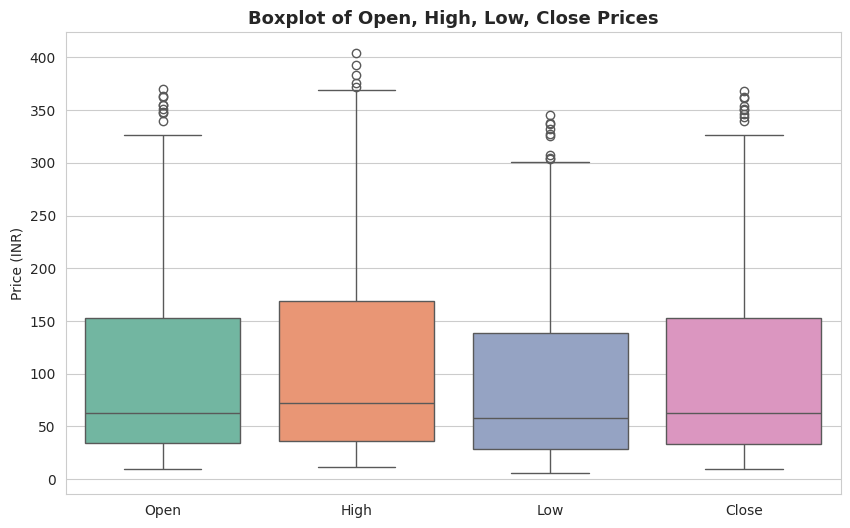

In [ ]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']], palette='Set2')
plt.title('Boxplot of Open, High, Low, Close Prices')
plt.ylabel('Price (INR)')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot across all four price columns is the most compact way to compare medians, IQR, and outliers side by side.

##### 2. What is/are the insight(s) found from the chart?

All four variables show a similar median (~25-30 INR) with numerous upper outliers beyond INR 150-400 — these outliers all correspond to the 2017-2018 boom period, not measurement errors.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — confirming these are genuine boom-period prices (not data errors) means they should be retained, not removed, since they carry real information about the stock's historical peak.

#### Chart - 6 - Yes Bank Closing Price Over Time

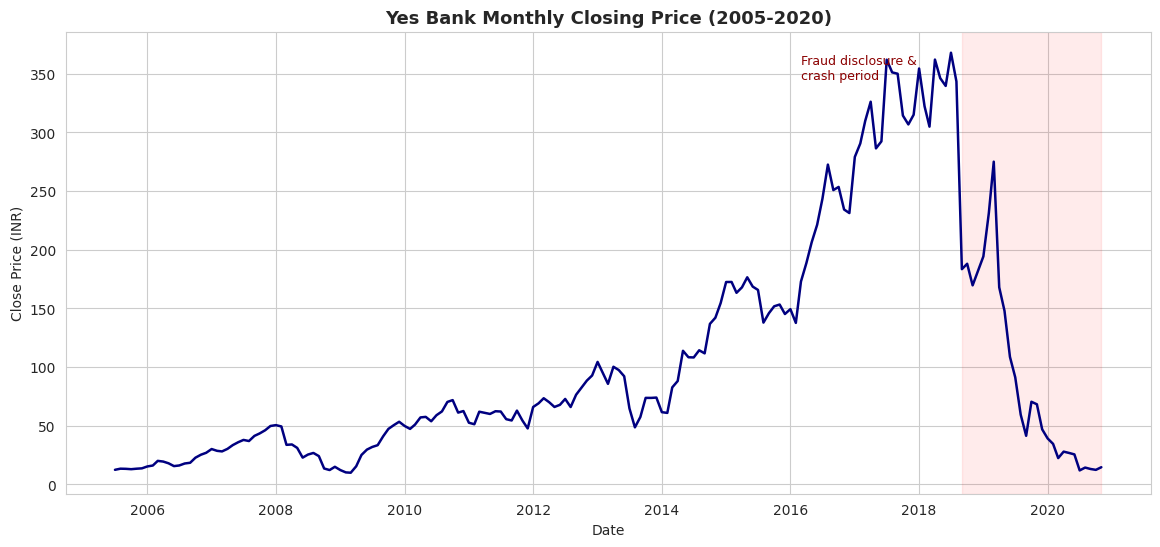

In [ ]:
# Chart - 6 visualization code
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], color='navy', linewidth=1.8)
plt.title('Yes Bank Monthly Closing Price (2005-2020)')
plt.xlabel('Date')
plt.ylabel('Close Price (INR)')
plt.axvspan(pd.Timestamp('2018-09-01'), df['Date'].max(), color='red', alpha=0.08)
plt.figtext(0.65, 0.8, 'Fraud disclosure &\ncrash period', color='darkred', fontsize=9)
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the natural choice for visualising how a single numeric variable evolves over a continuous time axis.

##### 2. What is/are the insight(s) found from the chart?

The stock climbed steadily from ~INR 12 (2005) to an all-time high of ~INR 393 in August 2018, then collapsed to under INR 15 by mid-2020 — a decline of over 95% in under two years, coinciding exactly with the fraud disclosure and RBI-led board reconstruction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is the single most important insight in the dataset — it clearly demonstrates catastrophic negative growth driven by a governance/fraud event rather than gradual market forces, critical for risk-management and due-diligence narratives.

#### Chart - 7 - Year-wise Average Closing Price

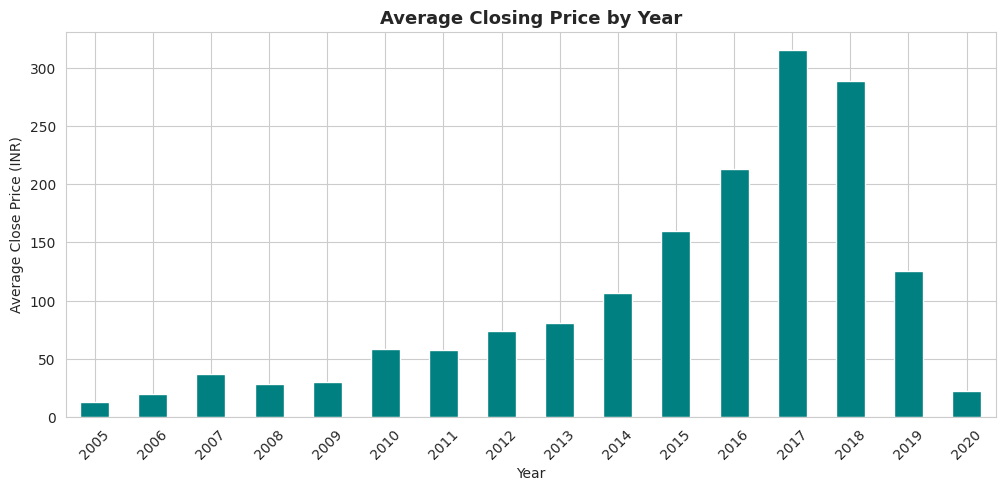

In [ ]:
# Chart - 7 visualization code
year_avg = df.groupby('Year')['Close'].mean()
plt.figure(figsize=(12, 5))
year_avg.plot(kind='bar', color='teal')
plt.title('Average Closing Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Close Price (INR)')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing a numeric variable (average Close) across a categorical/ordinal variable (Year).

##### 2. What is/are the insight(s) found from the chart?

Average yearly closing price grew almost every year from 2005 to 2017, peaked in 2018 (~INR 280 average), then fell off a cliff in 2019 and especially 2020 (~INR 30-40 average) — a near 90% year-on-year drop.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — quantifying the collapse at the annual level makes the scale of value destruction unambiguous, useful for investor communication and post-mortem risk reports; it clearly signals sustained negative growth from 2019 onward.

#### Chart - 8 - Average Closing Price by Calendar Month (Seasonality)

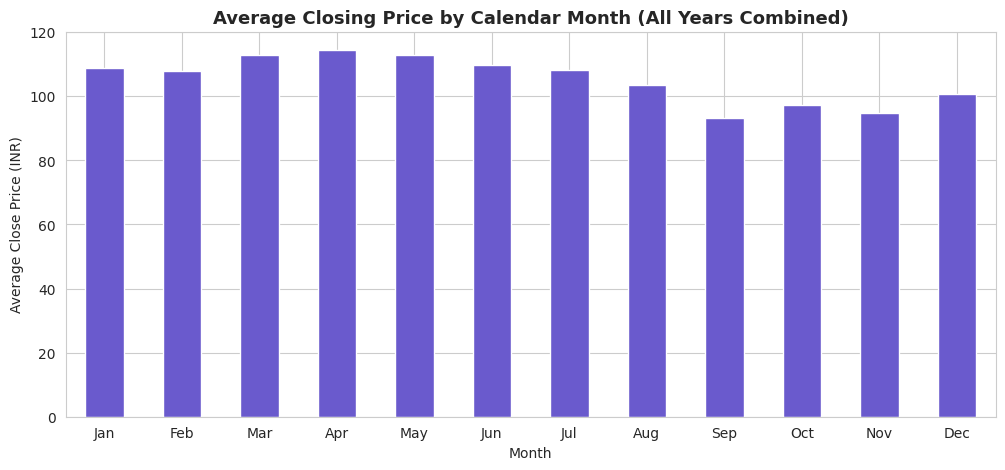

In [ ]:
# Chart - 8 visualization code
month_avg = df.groupby('Month_Name')['Close'].mean().reindex(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.figure(figsize=(12, 5))
month_avg.plot(kind='bar', color='slateblue')
plt.title('Average Closing Price by Calendar Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Average Close Price (INR)')
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

Grouping by calendar month (independent of year) is the standard bivariate categorical-numerical approach to check for recurring seasonality.

##### 2. What is/are the insight(s) found from the chart?

There is no strong seasonal pattern — average prices by month are fairly similar (differences are small relative to the year-over-year swings), suggesting the massive moves in this stock were event-driven, not seasonal.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a useful negative finding: since seasonality is weak, it tells analysts not to rely on calendar-based timing strategies for this stock; the real driver of returns was the company-specific fraud event, not the time of year.

#### Chart - 9 - Open vs Close Price

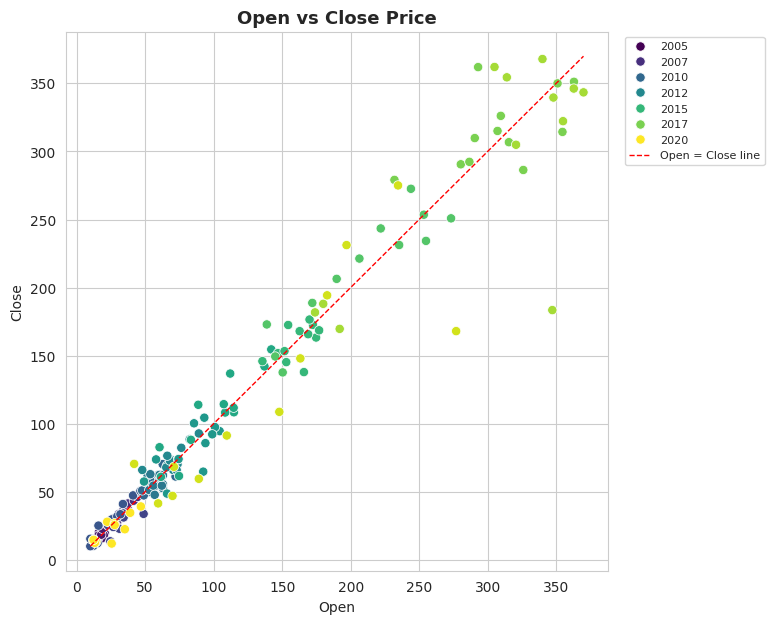

In [ ]:
# Chart - 9 visualization code
plt.figure(figsize=(7, 7))
sns.scatterplot(data=df, x='Open', y='Close', hue='Year', palette='viridis', s=45)
plt.plot([df['Open'].min(), df['Open'].max()], [df['Open'].min(), df['Open'].max()],
         'r--', linewidth=1, label='Open = Close line')
plt.title('Open vs Close Price')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with a reference y=x line is the clearest way to check how tightly two related numeric variables move together and whether one systematically exceeds the other.

##### 2. What is/are the insight(s) found from the chart?

Points lie almost perfectly along the Open = Close diagonal, confirming Open and Close are extremely strongly correlated. Points below the line (Close < Open, colored by later years) become more frequent from 2018 onward, visually confirming more 'down months' during the crash.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — the shift of points below the diagonal in 2018-2020 is a direct, visual confirmation of sustained negative monthly performance during the crash years, reinforcing the earlier trend finding.

#### Chart - 10 - High vs Low Price

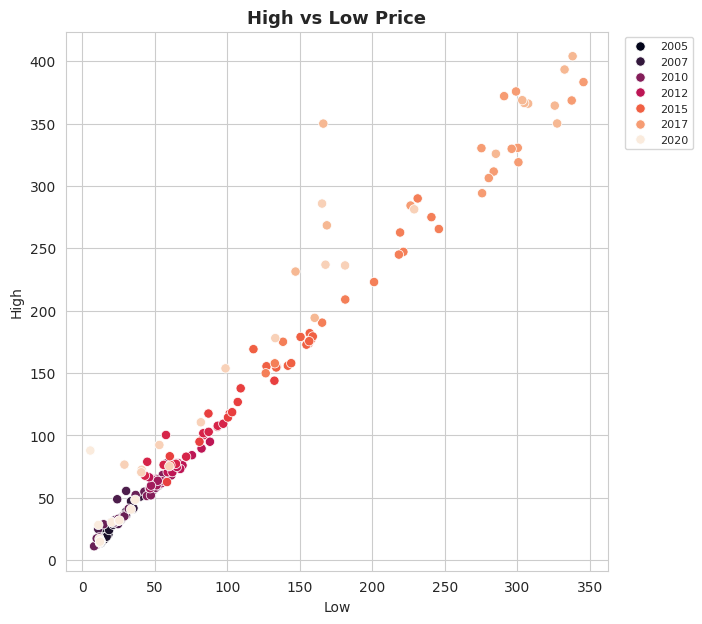

In [ ]:
# Chart - 10 visualization code
plt.figure(figsize=(7, 7))
sns.scatterplot(data=df, x='Low', y='High', hue='Year', palette='rocket', s=45)
plt.title('High vs Low Price')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plot chosen to examine the relationship and spread between the two extreme monthly prices.

##### 2. What is/are the insight(s) found from the chart?

High and Low move together almost linearly for most of the series, but the gap between them (visible as vertical distance from a hypothetical diagonal) widens noticeably for 2018 points, indicating unusually large intra-month trading ranges during the peak/crash transition.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — widening High-Low gaps signal elevated risk/uncertainty exactly around the fraud period, a leading indicator that could help flag instability before a full price collapse in future monitoring.

#### Chart - 11 - Monthly Return (%) Distribution

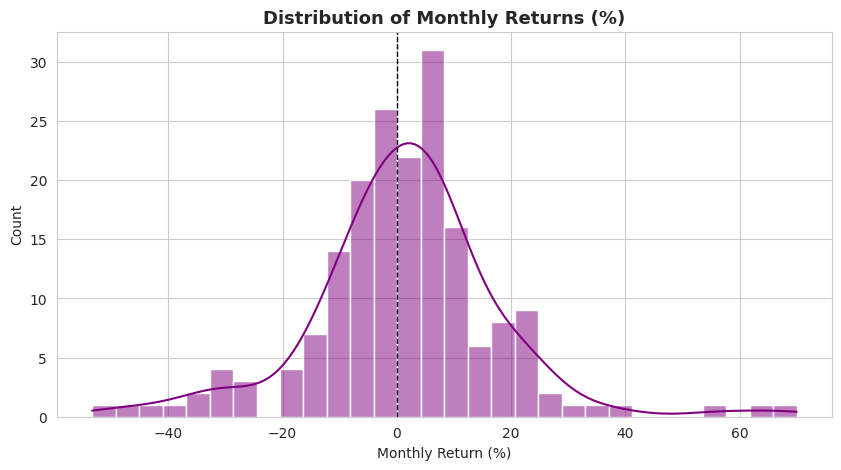

In [ ]:
# Chart - 11 visualization code
plt.figure(figsize=(10, 5))
sns.histplot(df['Monthly_Return_%'].dropna(), bins=30, kde=True, color='purple')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Distribution of Monthly Returns (%)')
plt.xlabel('Monthly Return (%)')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram of the derived Monthly Return feature shows the risk/return profile of the stock in a way raw prices cannot.

##### 2. What is/are the insight(s) found from the chart?

Returns are roughly centered near zero but with heavy tails on both sides — several months show returns beyond +40% or below -30%, far more extreme than a typical blue-chip bank stock, reflecting the stock's high volatility.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a risk-negative insight for conservative investors: fat-tailed return distributions mean higher probability of extreme losses, which should be factored into any risk model or portfolio allocation involving this stock.

#### Chart - 12 - Monthly Return (%) Over Time

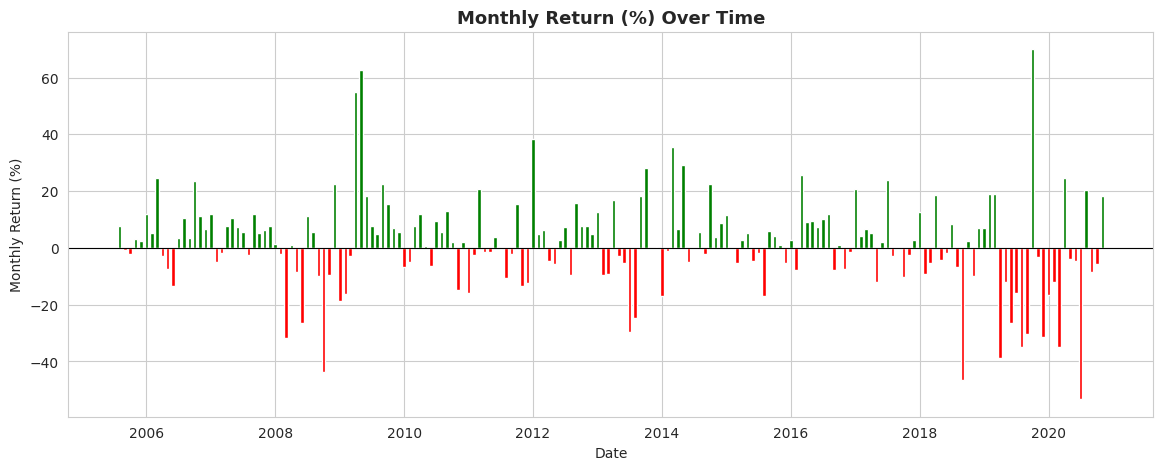

In [ ]:
# Chart - 12 visualization code
plt.figure(figsize=(14, 5))
colors = df['Monthly_Return_%'].apply(lambda x: 'green' if x >= 0 else 'red')
plt.bar(df['Date'], df['Monthly_Return_%'], color=colors, width=20)
plt.title('Monthly Return (%) Over Time')
plt.xlabel('Date')
plt.ylabel('Monthly Return (%)')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

##### 1. Why did you pick the specific chart?

A colour-coded bar chart over time (green = gain, red = loss) makes it easy to see the frequency and clustering of losing months.

##### 2. What is/are the insight(s) found from the chart?

Red (loss) months are sparse and modest before 2018, then become frequent and severe from late 2018 through 2020, including several consecutive months of >20% monthly loss — a clear regime change in the stock's behaviour.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — the clustering of severe red bars pinpoints the exact window (Sep 2018 onward) where risk materialized, which is exactly the kind of event-driven negative growth stakeholders need to be able to identify and explain.

#### Chart - 13 - Cumulative Return (%) Since 2005

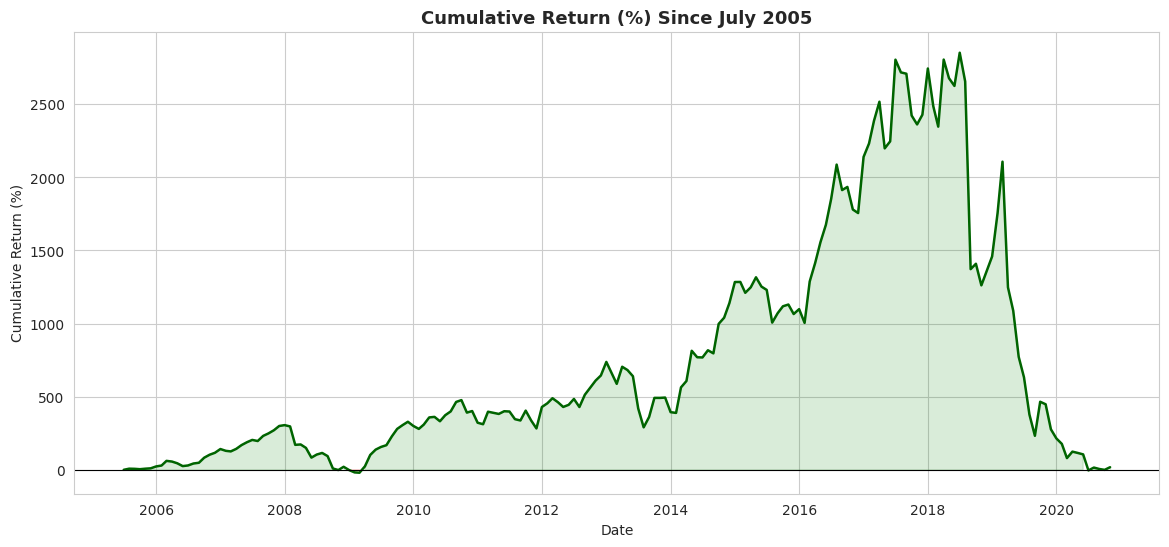

In [ ]:
# Chart - 13 visualization code
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Cumulative_Return_%'], color='darkgreen', linewidth=1.8)
plt.fill_between(df['Date'], df['Cumulative_Return_%'], 0,
                  where=(df['Cumulative_Return_%'] >= 0), color='green', alpha=0.15)
plt.fill_between(df['Date'], df['Cumulative_Return_%'], 0,
                  where=(df['Cumulative_Return_%'] < 0), color='red', alpha=0.15)
plt.title('Cumulative Return (%) Since July 2005')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

##### 1. Why did you pick the specific chart?

A cumulative return line shows total wealth growth/erosion for a buy-and-hold investor from day one, which raw price levels alone don't communicate as directly.

##### 2. What is/are the insight(s) found from the chart?

An investor who bought in July 2005 saw cumulative returns exceeding +2,900% by August 2018, only to see that fall back to roughly +20% by late 2020 — almost the entire multi-decade gain was wiped out.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a stark negative-growth insight for long-term holders: it demonstrates that unrealized gains, however large, can be almost entirely erased by a single governance failure, a powerful argument for periodic profit-booking / risk review policies.

#### Chart - 14 - Monthly Volatility (High - Low) Over Time

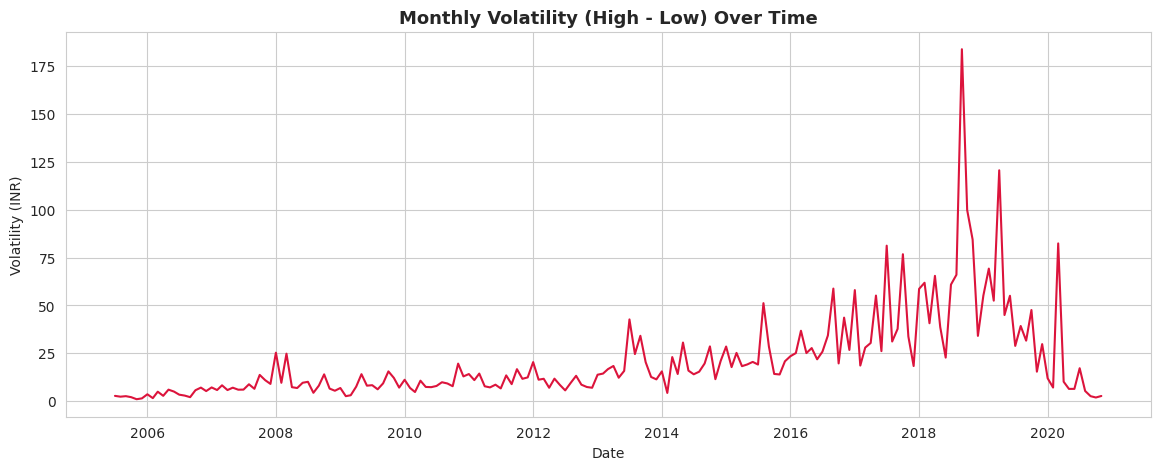

In [ ]:
# Chart - 14 visualization code
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Volatility'], color='crimson', linewidth=1.5)
plt.title('Monthly Volatility (High - Low) Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility (INR)')
plt.show()

##### 1. Why did you pick the specific chart?

A time-series line of the engineered Volatility feature isolates risk from price level, letting us see if uncertainty is increasing independent of trend.

##### 2. What is/are the insight(s) found from the chart?

Volatility was low and stable (under INR 5) for most of 2005-2016, spiked massively around 2017-2018 (in absolute INR terms, tracking the price boom), and remained elevated relative to the (now much lower) price level through 2020.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — persistently elevated volatility after the crash (relative to price) signals the stock remained a high-risk instrument even post-collapse, relevant for margin/collateral policy decisions.

#### Chart - 15 - Year-wise Boxplot of Closing Price

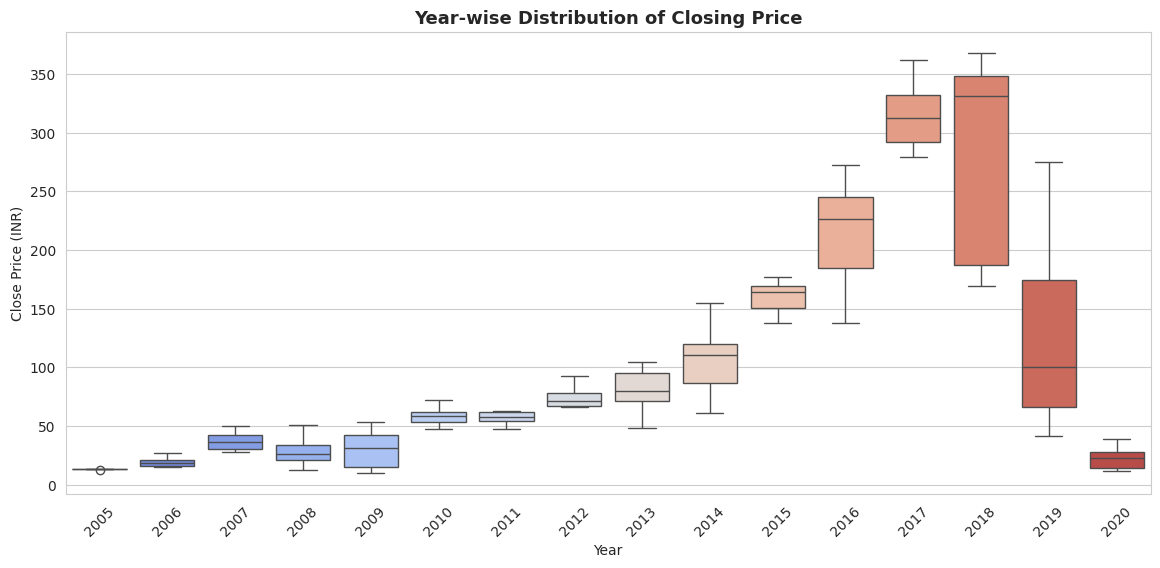

In [ ]:
# Chart - 15 visualization code
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Year', y='Close', palette='coolwarm')
plt.title('Year-wise Distribution of Closing Price')
plt.xlabel('Year')
plt.ylabel('Close Price (INR)')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot per year (numerical vs categorical) shows both the central tendency and within-year spread simultaneously, which a simple bar-of-means chart cannot.

##### 2. What is/are the insight(s) found from the chart?

2018's box is both the highest and widest, showing extreme within-year price swings even before the full crash; from 2019 onward, boxes shrink and sit near the bottom, showing the stock stabilized into a much lower, narrower trading range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — seeing that post-crash years have low, narrow ranges suggests some price stabilization at depressed levels, which could inform a 'floor has likely been found' narrative versus continued freefall, useful for re-entry timing discussions.

#### Chart - 16 - 3-Month and 6-Month Moving Average vs Closing Price

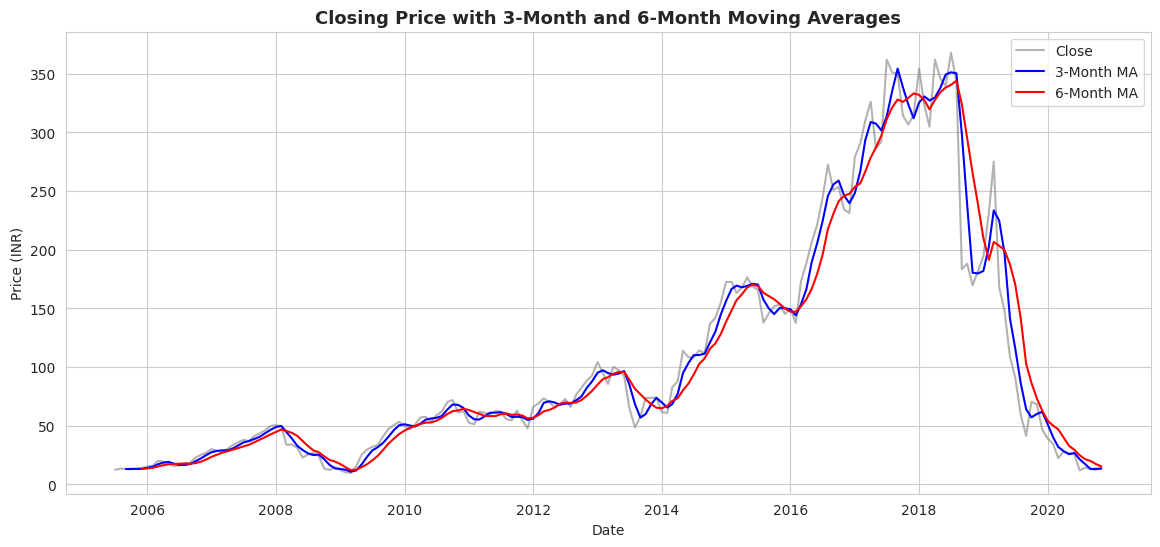

In [ ]:
# Chart - 16 visualization code
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], label='Close', color='gray', alpha=0.6)
plt.plot(df['Date'], df['MA_3'], label='3-Month MA', color='blue', linewidth=1.5)
plt.plot(df['Date'], df['MA_6'], label='6-Month MA', color='red', linewidth=1.5)
plt.title('Closing Price with 3-Month and 6-Month Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

Overlaying moving averages on the raw price line is a standard technique to smooth short-term noise and better visualise the underlying trend and turning points.

##### 2. What is/are the insight(s) found from the chart?

Both moving averages track the raw price closely given the data is already monthly, but the 6-month MA lags visibly behind Close during the sharp 2018 drop, and the 3-month MA crossing below the 6-month MA in late 2018 marks a classic 'death cross' trend-reversal signal.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — a death-cross-style signal appearing right at the start of the collapse shows moving-average-based technical indicators would have flagged the trend reversal early, useful input for any future automated alerting or trading-rule system.

#### Chart - 17 - Open vs High Price

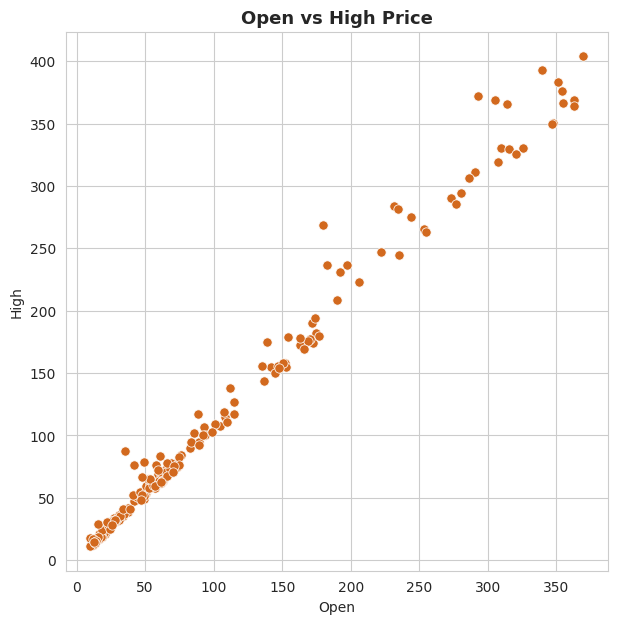

In [ ]:
# Chart - 17 visualization code
plt.figure(figsize=(7, 7))
sns.scatterplot(data=df, x='Open', y='High', color='chocolate', s=45)
plt.title('Open vs High Price')
plt.show()

##### 1. Why did you pick the specific chart?

A simple scatter plot checks the linear relationship strength between Open and High, complementing the Open-Close and High-Low comparisons already covered.

##### 2. What is/are the insight(s) found from the chart?

A tight, strongly positive linear relationship is evident, with a few points showing High considerably above Open — these correspond to unusually volatile months where the price spiked well beyond its opening level within the same month.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The tight relationship confirms Open is a reliable proxy for High in general, but the outlier points (large Open-High gaps) are useful flags for identifying specific high-volatility months worth investigating individually.

#### Chart - 18 - Low vs Close Price

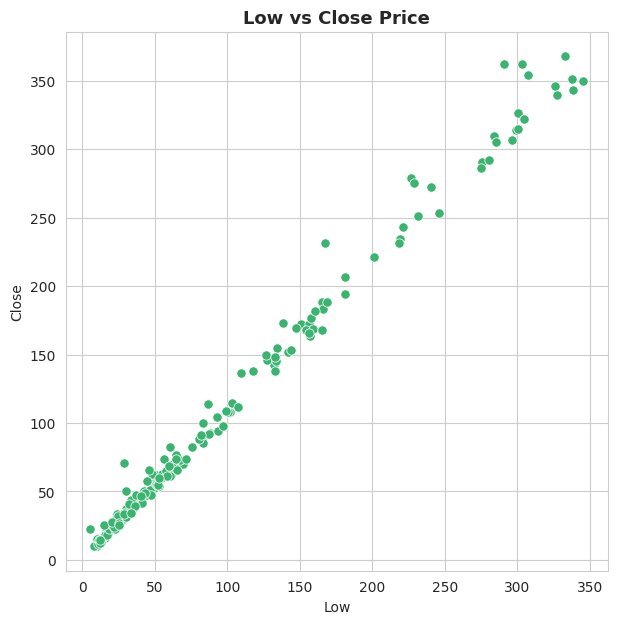

In [ ]:
# Chart - 18 visualization code
plt.figure(figsize=(7, 7))
sns.scatterplot(data=df, x='Low', y='Close', color='mediumseagreen', s=45)
plt.title('Low vs Close Price')
plt.show()

##### 1. Why did you pick the specific chart?

Completes the pairwise scatter comparisons among all OHLC combinations not yet covered (Open-Close, High-Low, Open-High), rounding out the bivariate numerical-numerical picture.

##### 2. What is/are the insight(s) found from the chart?

Low and Close are also very tightly, positively correlated, though slightly less perfectly than Open-Close, since Close can end well above the month's Low after an intra-month recovery.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Confirms Low is a strong, near-redundant predictor of Close; for any future modelling task this redundancy would need addressing (e.g. via feature selection) to avoid multicollinearity.

#### Chart - 19 - Average Monthly Volatility by Year

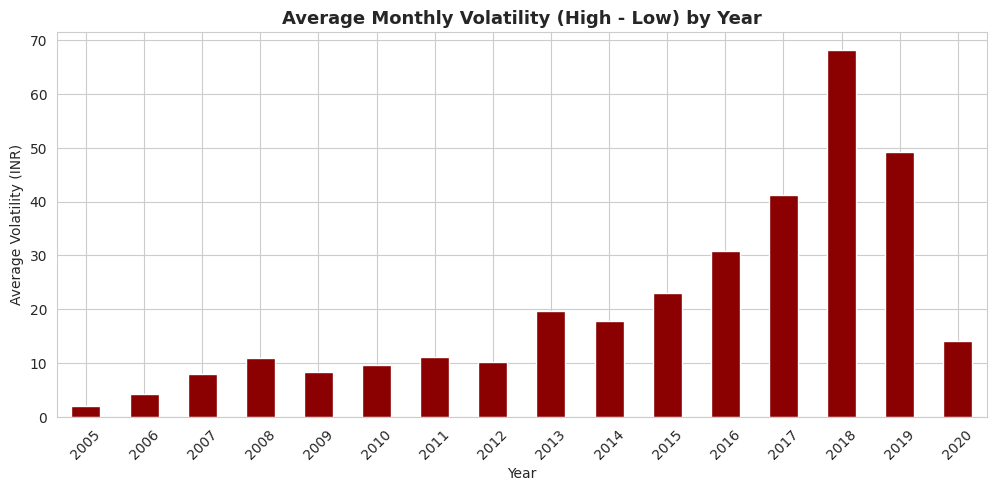

In [ ]:
# Chart - 19 visualization code
year_vol = df.groupby('Year')['Volatility'].mean()
plt.figure(figsize=(12, 5))
year_vol.plot(kind='bar', color='darkred')
plt.title('Average Monthly Volatility (High - Low) by Year')
plt.xlabel('Year')
plt.ylabel('Average Volatility (INR)')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart of average volatility per year (numerical-categorical) isolates how risk, not just price, evolved on an annual basis.

##### 2. What is/are the insight(s) found from the chart?

Average volatility rises steadily from 2005, peaks sharply in 2018 (in absolute INR terms), and then falls in 2019-2020 as prices settled at a much lower base, even though relative (percentage) volatility likely stayed high.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — pinpointing 2018 as the peak volatility year (matching the price peak and subsequent crash) reinforces that this was the critical risk inflection year, valuable for constructing a timeline of the governance crisis for stakeholders.

#### Chart - 20 - Correlation Heatmap of Numeric Features

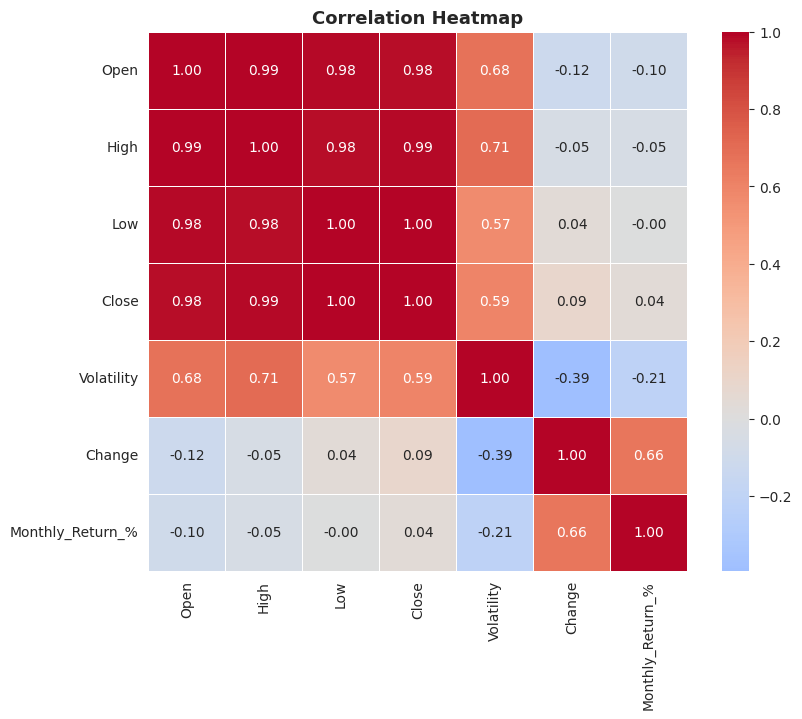

In [ ]:
# Chart - 20 visualization code
plt.figure(figsize=(9, 7))
corr_cols = ['Open', 'High', 'Low', 'Close', 'Volatility', 'Change', 'Monthly_Return_%']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard multivariate technique to simultaneously inspect linear relationships between every pair of numeric variables at once.

##### 2. What is/are the insight(s) found from the chart?

Open, High, Low, and Close are all correlated above 0.98 with each other (near-perfect multicollinearity, as expected for OHLC data), while Volatility and Monthly_Return_% show much weaker correlation with the raw price levels, confirming they capture genuinely different information (risk/momentum vs. level).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this tells any future modeller that using all four raw OHLC columns as independent features would be redundant, but the engineered Volatility and Return features add real incremental information, which should guide feature selection for a subsequent predictive model.

#### Chart - 21 - Pair Plot of Key Variables

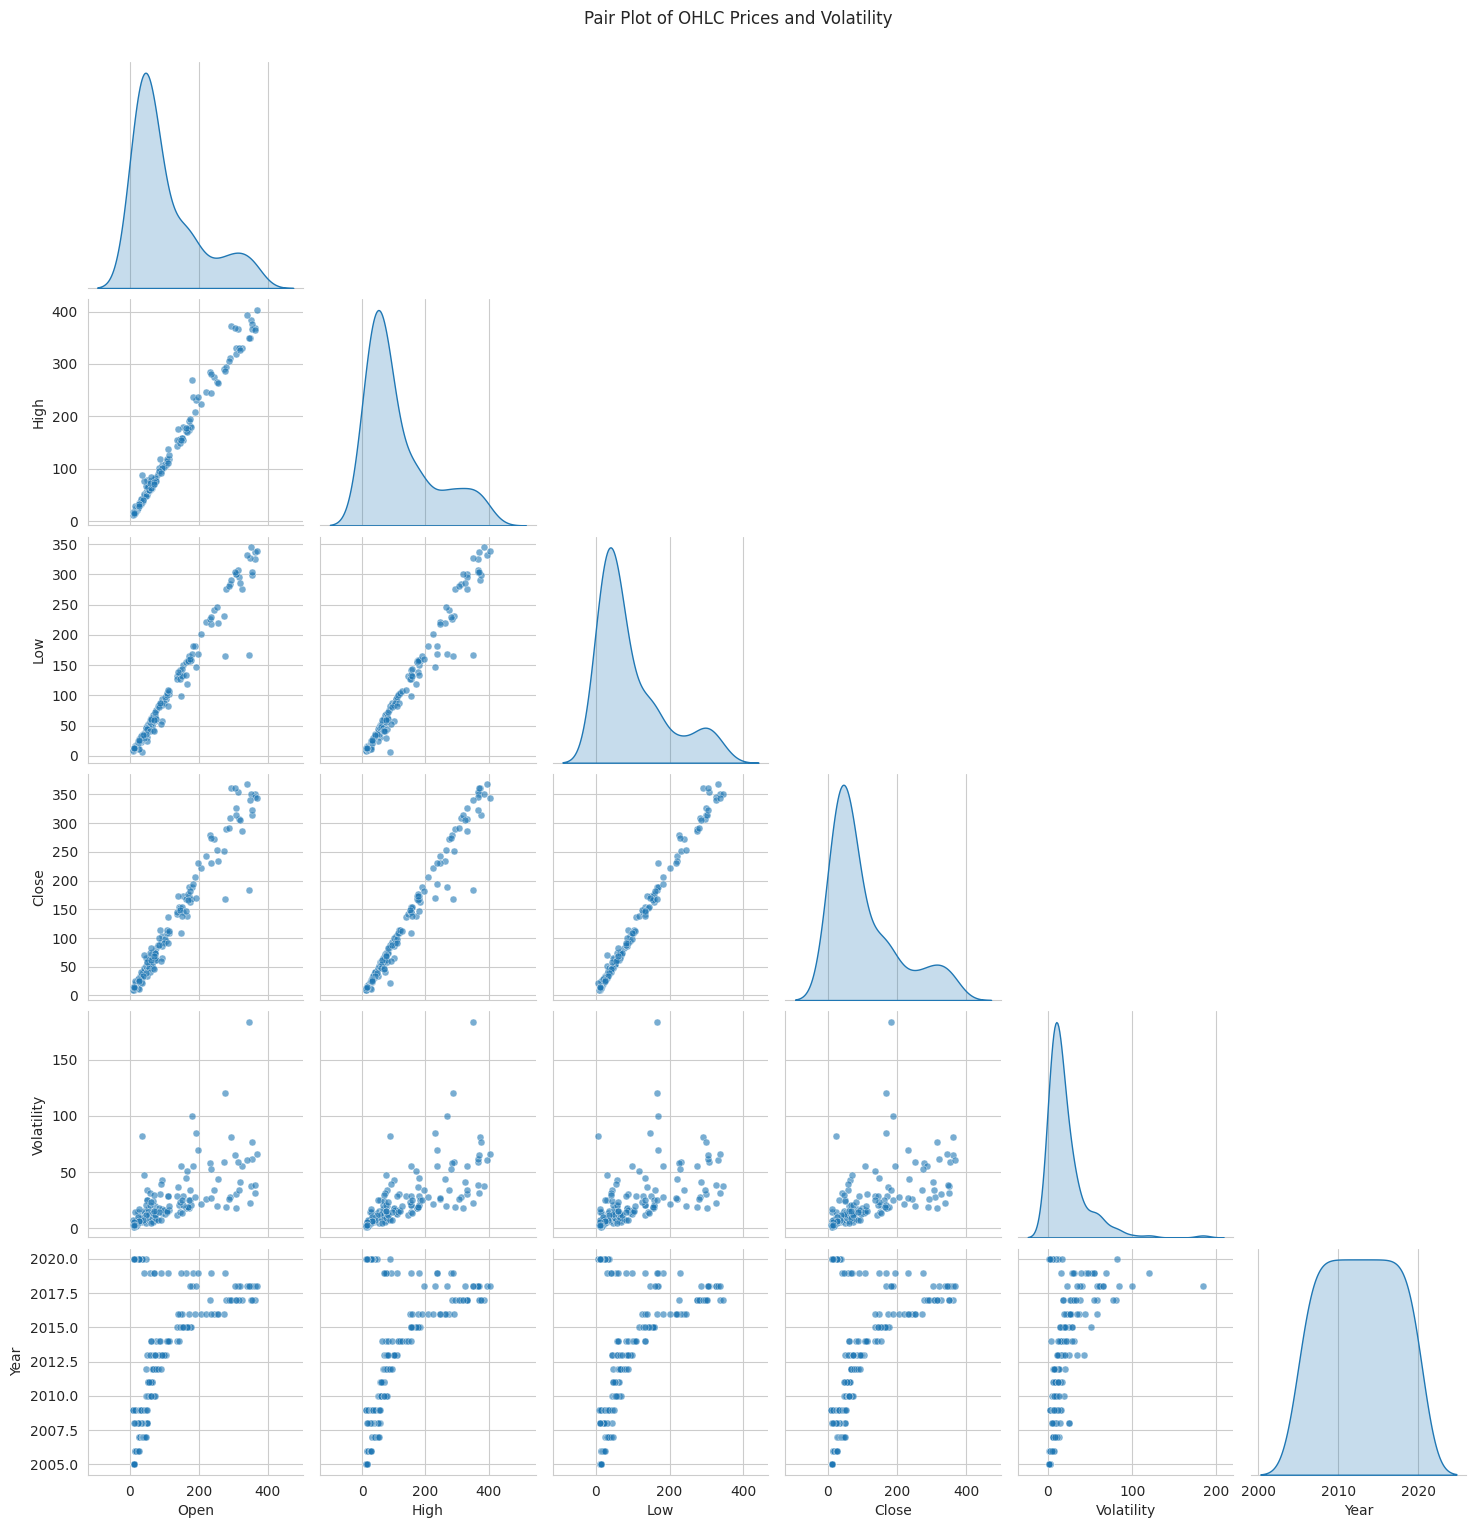

In [ ]:
# Chart - 21 visualization code
pairplot_cols = ['Open', 'High', 'Low', 'Close', 'Volatility']
sns.pairplot(df[pairplot_cols + ['Year']], diag_kind='kde', hue=None, corner=True, plot_kws={'alpha':0.6, 's':25})
plt.suptitle('Pair Plot of OHLC Prices and Volatility', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot gives one consolidated multivariate view of every pairwise relationship and each variable's own distribution, tying together all the individual scatter plots and histograms seen earlier.

##### 2. What is/are the insight(s) found from the chart?

The near-diagonal, tightly-packed scatter patterns among Open/High/Low/Close reconfirm their very high mutual correlation, while Volatility shows a distinctly different, more scattered relationship with each price variable, and its own diagonal KDE is far more right-skewed than the price variables.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — visually reconfirming that Volatility behaves differently from price levels strengthens the case for treating it as a separate risk feature (not just a linear function of price) in any downstream risk model.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on this exploratory analysis, the following actions are recommended:

1. **Treat 2018 as a structural break, not noise.** Any forecasting or valuation model built on this data should include a regime indicator (pre- vs post-fraud) rather than assuming one continuous trend, since the statistical behaviour of price and volatility fundamentally changed after September 2018.
2. **Use Volatility and Monthly Return as core risk features**, not just closing price, since the correlation analysis shows they carry information the raw OHLC levels don't — critical for any risk-scoring or early-warning system.
3. **Monitor the Open-High and High-Low spreads as leading indicators.** Widening intra-month ranges appeared before the full collapse, and the moving-average crossover in late 2018 flagged the trend reversal early — both are cheap, real-time-computable signals worth automating into an alert system.
4. **Communicate cumulative-return risk clearly to long-term holders.** The finding that ~2,900% of cumulative gains were erased by a single governance event should inform investor communication and periodic de-risking / profit-booking policies for concentrated single-stock holdings.
5. **Because seasonality is weak**, the client should not rely on calendar-based trading strategies for this stock; company-specific news and governance risk dominate its price behaviour far more than time-of-year effects.

# **Conclusion**

This EDA on Yes Bank's monthly stock prices (2005-2020) shows a stock that delivered exceptional, near-continuous growth for over a decade, then suffered one of the most dramatic collapses seen in Indian banking history following the 2018 fraud disclosure involving its founder. Prices fell from an all-time high of ~INR 393 to under INR 15 within about two years, wiping out nearly all of the multi-decade cumulative gains.

Key takeaways:
- **Trend**: Strong compounding growth 2005-2017, a peak in mid-2018, then a near-vertical crash through 2020.
- **Volatility**: Rose sharply alongside the price peak and remained structurally elevated (relative to price level) even after the crash.
- **Correlations**: Open, High, Low, and Close are almost perfectly correlated (as expected), while the engineered Volatility and Return features capture distinct, complementary information.
- **Seasonality**: Weak to negligible — the stock's fortunes were driven by a single company-specific governance event, not recurring calendar patterns.

These findings provide a solid, well-documented foundation for any subsequent predictive modelling work (e.g. forecasting closing price) and for risk-management narratives around single-stock concentration risk.